In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors

import pathlib
import sys

sys.path.append(r"C:\Users\TJFerron\Documents\Github\pypxr\src\pypxr")
sys.path.append(r"C:\Users\TJFerron\Desktop")

from prsoxr_loader_ALS_quickfix_v5 import *
#from prsoxr_loader_new import *

In [2]:
def sort_by_last_four_digits(path):
    """Extracts the last four digits from the filename for sorting."""
    filename = path.name  # Get the filename part (e.g., 'SOC4 003206 CCD 008.fits')
    # Find the last occurrence of a digit sequence
    import re
    match = re.search(r'(\d{3})\d\.fits$', filename) # Modified regex to capture the relevant part
    if match:
        return int(match.group(0)[:-5]) # Extract the digits and convert to integer
    return -1 # Handle cases where the pattern isn't found (sort at the beginning)


In [3]:
#path_s = pathlib.Path(r"C:\Users\TJFerron\Desktop\SOC4 003206 Images")
TCTA_100_P100 = "TCTA_100_P100_ 002042"
TCTA_100_P190 = "TCTA_100_P190_ 002248"
TCTA_75_P100 = "TCTA_75_P100_ 002043"
TCTA_75_P190 = "TCTA_75_P190_ 002249"
TCTA_50_P100 = "TCTA_50_P100_ 002044"
TCTA_50_P190 = "From File Scan 006285" #TCTA_50_P190_ 002250"
TCTA_25_P190 = "T25 006288"
TCTA_5_P190 = "T5 006287"
TCTA_0_P100 = "TCTA_0_P100_ 002045"
TCTA_0_P190 = "T0 006286"

path = pathlib.Path(r"C:\Users\TJFerron\Documents\Temp_Data\XRR_Glass\DATA")

sample_list_P100 = [TCTA_100_P100, TCTA_75_P100, TCTA_50_P100, TCTA_0_P100]
sample_list_P190 = [TCTA_100_P190, TCTA_75_P190, TCTA_50_P190, TCTA_0_P190, TCTA_25_P190, TCTA_5_P190]
#path_s = pathlib.Path(r"C:\Users\TJFerron\Desktop")
#C:\Users\TJFerron\Documents\Temp_Data\XRR_Fink

In [4]:
loaders_P100 = []
for sample in sample_list_P100:
    fits_folder = f"{sample} Images"
    fits_path = path / fits_folder
    fits_glob = list(fits_path.glob('*fits'))
    
    text_glob = list(path.glob(sample+'*.txt'))
    loaders_P100.append(PrsoxrLoader(sorted(fits_glob, key=sort_by_last_four_digits), text_glob[0]))

In [5]:
loaders_P190 = []
for sample in sample_list_P190:
    fits_folder = f"{sample} Images"
    fits_path = path / fits_folder
    fits_glob = list(fits_path.glob('*fits'))
    
    text_glob = list(path.glob(sample+'*.txt'))
    loaders_P190.append(PrsoxrLoader(sorted(fits_glob, key=sort_by_last_four_digits), text_glob[0]))

In [6]:
mask_P100 = np.zeros_like(loaders_P100[0]._images[0], dtype=int)
mask_P100[105:145,50:250] = 1
for loader in loaders_P100:
    loader.mask = mask_P100

In [7]:
mask_P190 = np.zeros_like(loaders_P190[0]._images[0], dtype=int)
mask_P190[105:155,50:250] = 1
for loader in loaders_P190[:2]:
    loader.mask = mask_P190

mask_P190_2 = np.zeros_like(loaders_P190[2]._images[0], dtype=int)
mask_P190_2[30:220,50:280] = 1
for loader in loaders_P190[2:]:
    loader.mask = mask_P190_2

In [8]:
# ANgle Offsets to reload data --- 
TCTA_100_P100_ao = 0.006
TCTA_100_P190_ao = -0.004
TCTA_75_P100_ao = -0.006
TCTA_75_P190_ao = -0.008
TCTA_50_P100_ao = -0.016
TCTA_50_P190_ao = -0.006 #TCTA_50_P190_ 002250"
TCTA_25_P190_ao = 0.058
TCTA_5_P190_ao = 0.03
TCTA_0_P100_ao = -0.014
TCTA_0_P190_ao = 0.042
aoffset_100 = [TCTA_100_P100_ao, TCTA_75_P100_ao, TCTA_50_P100_ao, TCTA_0_P100_ao]
aoffset_190 = [TCTA_100_P190_ao, TCTA_75_P190_ao, TCTA_50_P190_ao, TCTA_0_P190_ao, TCTA_25_P190_ao, TCTA_5_P190_ao]

In [9]:
# Do angle of offsets:
for i, loader in enumerate(loaders_P100):
    loader.angle_offset = aoffset_100[i]
for i, loader in enumerate(loaders_P190):
    loader.angle_offset = aoffset_190[i]
    

In [10]:
loaders_P190[3].angle_offset

0.042

In [11]:
loaders_P190[3].PXRImages[11].angle

0.958

In [12]:
1.-0.958

0.04200000000000004

Exposure: 0.0
Beam Current: 0
Angle Theta: 0.958
T-2T: 0.958
CCD Theta: 2.0
Photon Energy: 250.0
Polarization: 190.0
Higher Order Suppressor: 8.79998959
Horizontal Exit Slit Size: 2999.9921875


Processed Variables:
Q: 0.004421783489086464
Specular: 174438
Background: 164185
Signal: 10253
SNR: 0.06244784846362335
Beam center (np.int64(79), np.int64(160))


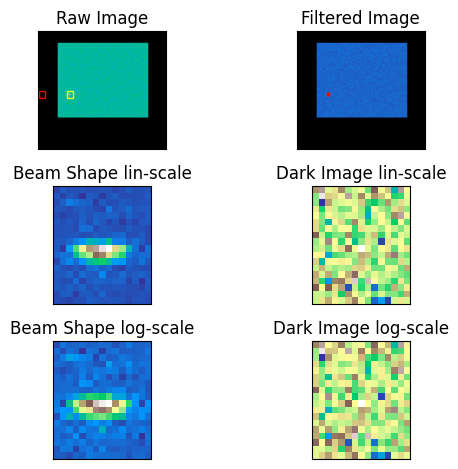

In [13]:
a = loaders_P190[3].check_spot(11)

In [14]:
refl_P100 = []
for loader in loaders_P100:
    refl_P100.append(loader())

C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])


In [15]:
refl_P190 = []
for loader in loaders_P190:
    refl_P190.append(loader())

C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_loader_ALS_quickfix_v5.py:1223: OdrWarning: Empty data detected for ODR instance. Do not expect any fitting to occur
  myodr = ODR(mydata, linear, beta0=[1.0])
C:\Users\TJFerron\Desktop\prsoxr_lo

In [16]:
refl_P100_group = []
for refl in refl_P100:
    refl_temp = refl.groupby(["Theta", 'Energy', 'Polarization'], as_index=False).mean()
    refl_temp = refl_temp[refl_temp['R']>0]
    refl_P100_group.append(refl_temp)
refl_P190_group = []
for refl in refl_P190:
    refl_temp = refl.groupby(["Theta", 'Energy', 'Polarization'], as_index=False).mean()
    refl_temp = refl_temp[refl_temp['R']>0]
    refl_P190_group.append(refl_temp)

In [17]:
energy_list = loaders_P190[0].meta['Beamline Energy'].unique()

In [18]:
energy_list

array([250.  , 283.5 , 283.75, 284.  , 284.25, 284.5 , 286.4 , 286.6 ,
       286.8 , 287.  , 287.2 ])

In [19]:
#refl_P190_group

284.5


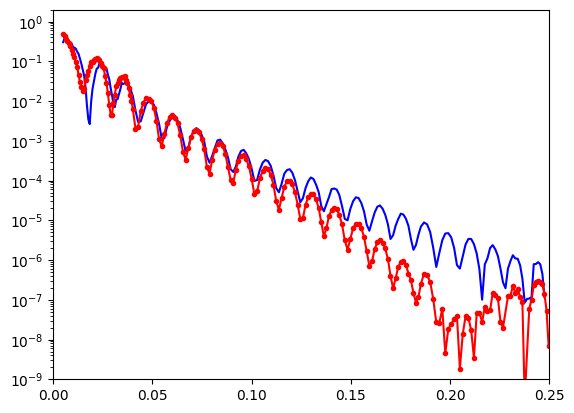

In [30]:
fig, ax = plt.subplots(1,1)
energy_index = 5
sample_index = 1
energy = energy_list[energy_index]
print(energy)
xrr_100 = refl_P100_group[sample_index]
xrr_190 = refl_P190_group[sample_index]

ax.plot(xrr_100[xrr_100['Energy']==energy].Q, xrr_100[xrr_100['Energy']==energy].R, color='blue')
ax.plot(xrr_190[xrr_190['Energy']==energy].Q, xrr_190[xrr_190['Energy']==energy].R, color='red',marker= '.')
plt.xlim(0.0,0.25)
plt.ylim(1e-9,2)
plt.yscale('log')

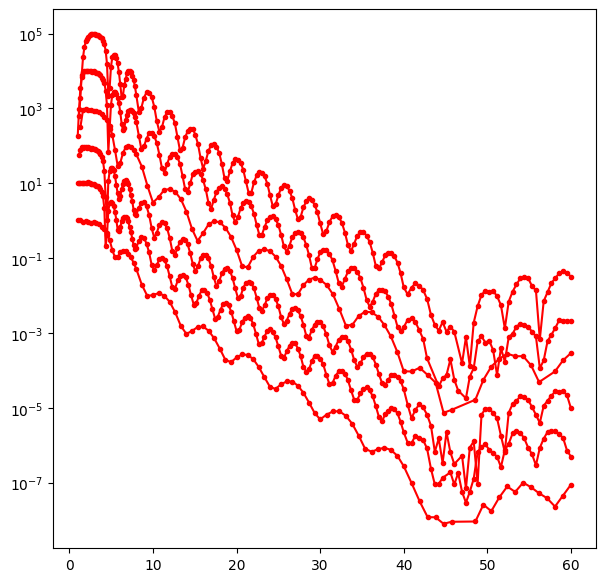

In [24]:
fig, ax = plt.subplots(1,1, figsize=(7,7))
energy_index = 0
energy = energy_list[energy_index]
for i, xrr in enumerate(refl_P190_group):
    xw = xrr[xrr['Energy']==energy].Theta
    yw = xrr[xrr['Energy']==energy].R
    ax.plot(xw, yw*10**i, color='r', marker='.')
    #xrr[xrr['Energy']==energy].plot(x='Q',y='R', marker='.', ax=ax, stacked=True)
#for i, xrr in enumerate(refl_P100_group):
    #xw = xrr[xrr['Energy']==energy].Q
    #yw = xrr[xrr['Energy']==energy].R
    #ax.plot(xw, yw*10**i, color='blue')
    #xrr[xrr['Energy']==energy].plot(x='Q',y='R', marker='.', ax=ax)

#refl[refl['Energy']==energy].plot(x='Theta',y='R', marker='.', ax=ax)
#refl_190[refl_190['Energy']==energy].plot(x='Theta',y='R', marker='.', ax=ax)
#refl_75_P100[refl_75_P100['Energy']==energy].plot(x='Theta',y='R', marker='.', ax=ax)
#refl_75_P190[refl_75_P190['Energy']==energy].plot(x='Theta',y='R', marker='.', ax=ax)


plt.yscale('log')
#plt.ylim(0.01,1e5)
#plt.xlim(0.0,3)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4,8))
index = 0
x00 = refl_P100_group[index]
x90 = refl_P190_group[index]
for i, en in enumerate([energy_list[5]]):
    th_00 = x00[x00['Energy']==en].Theta
    q_00 = x00[x00['Energy']==en].Q
    r_00 = x00[x00['Energy']==en].R
    
    th_90 = x90[x90['Energy']==en].Theta
    q_90 = x90[x90['Energy']==en].Q
    r_90 = x90[x90['Energy']==en].R

    #ani_q = np.unique(np.concatenate([q_00, q_90]))
    #ani_num = np.interp(ani_q, q_00, r_00) - np.interp(ani_q, q_90, r_90)
    #ani_den = np.interp(ani_q, q_00, r_00) + np.interp(ani_q, q_90, r_90)*np.cos(th_00)
    #ax.plot(ani_q, ani_num/ani_den)
    ax.plot(q_00, r_00*100**i, color='r', ms=1, lw=0, marker='o')
    ax.plot(q_90, r_90*100**i, color='b', ms=1, lw=0, marker='o')
    #xrr[xrr['Energy']==en
#ax.set_yscale('log')
#plt.xlim(0,0.2)
#plt.ylim(1e-5,1e20)



In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4,8))
index = 1
x00 = refl_P100_group[index]
x90 = refl_P190_group[index]
for i, en in enumerate(energy_list[:-1]):
    th_00 = x00[x00['Energy']==en].Theta
    q_00 = x00[x00['Energy']==en].Q
    r_00 = x00[x00['Energy']==en].R
    
    th_90 = x90[x90['Energy']==en].Theta
    q_90 = x90[x90['Energy']==en].Q
    r_90 = x90[x90['Energy']==en].R

    ax.plot(q_00, r_00*100**i, color='r', ms=1, lw=0, marker='o')
    ax.plot(q_90, r_90*100**i, color='b', ms=1, lw=0, marker='o')
    #xrr[xrr['Energy']==en
ax.set_yscale('log')
#plt.xlim(0,0.2)
#plt.ylim(1e-5,1e20)


In [ ]:
ani_q

In [ ]:
pd.set_option('display.max_rows', None)

loaders_P100[0].meta[loaders_P100[0].meta['Beamline Energy']==287.2]['Sample Theta']

In [ ]:
th = np.arange(0,90,1)

In [ ]:
cos = np.cos(np.radians(th))

In [ ]:
plt.plot(th, cos)